# 03 - RFM user segmentation

## Business question

Not all users deserve the same operational investment. We need to answer:
- **Who are the high-value customers?** (priority for retention)
- **Who is about to churn?** (recall potential)
- **Who are the new customers?** (nurture to convert)
- **How to differentiate operations for different groups?**

RFM is the most common e-commerce segmentation model:
- **R**ecency: how recent was the last behavior
- **F**requency: behavior frequency
- **M**onetary: contribution value (we use "behavior diversity" since the data has no money)

In this dataset, almost every user purchases at some point, so we need to adapt the traditional RFM to fit this data.

In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import load_data, setup_plot_style, save_fig, DERIVED_DIR

setup_plot_style()
df = load_data()

# Reference date: end of dataset + 1 hour
reference_date = df['time'].max() + pd.Timedelta(hours=1)
print(f"Reference date: {reference_date}")

# R: days since last behavior
user_last_active = df.groupby('user_id')['time'].max()
R = (reference_date - user_last_active).dt.total_seconds() / 86400  # in days

# F: total behavior count in 30 days
F = df.groupby('user_id').size()

# M: behavior diversity = distinct categories engaged
M = df.groupby('user_id')['item_category'].nunique()

rfm = pd.DataFrame({'R': R, 'F': F, 'M': M}).reset_index()
print(f"Users: {len(rfm):,}")
print(f"\nR distribution: median {rfm['R'].median():.1f}d, P75 {rfm['R'].quantile(0.75):.1f}d")
print(f"F distribution: median {rfm['F'].median():.0f}, P75 {rfm['F'].quantile(0.75):.0f}")
print(f"M distribution: median {rfm['M'].median():.0f} categories, P75 {rfm['M'].quantile(0.75):.0f}")

Reference date: 2014-12-19 00:00:00


Users: 10,000

R distribution: median 0.4d, P75 1.4d
F distribution: median 747, P75 1547
M distribution: median 72 categories, P75 122


In [2]:
# Bin into 3 levels using quantiles
# R is reverse: lower R = higher score
rfm['R_score'] = pd.qcut(rfm['R'], q=3, labels=[3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['F'], q=3, labels=[1, 2, 3])
rfm['M_score'] = pd.qcut(rfm['M'], q=3, labels=[1, 2, 3])

rfm['RFM_sum'] = rfm['R_score'].astype(int) + rfm['F_score'].astype(int) + rfm['M_score'].astype(int)

# Business-meaningful 8 segments
def classify(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r == 3 and f == 3 and m == 3:
        return "Champions (high R/F/M)"
    elif r == 3 and (f == 3 or m == 3):
        return "Loyal customers (high R, growing F/M)"
    elif r >= 2 and f == 1 and m == 1:
        return "At-risk (high R, low F/M)"
    elif f >= 2 and m >= 2 and r == 1:
        return "Hibernating high-value (was active, now quiet)"
    elif f <= 2 and m <= 2 and r == 3:
        return "New customers (recent, light usage)"
    elif f >= 2 and r >= 2:
        return "Potential loyalists (active and growing)"
    elif f == 1 and m == 1 and r <= 2:
        return "Low-value dormant"
    else:
        return "Regular active"

rfm['segment'] = rfm.apply(classify, axis=1)
print("Segment distribution:")
print(rfm['segment'].value_counts())

Segment distribution:
segment
Potential loyalists (active and growing)          2384
Low-value dormant                                 1763
Champions (high R/F/M)                            1480
Hibernating high-value (was active, now quiet)    1138
At-risk (high R, low F/M)                         1047
New customers (recent, light usage)               1004
Regular active                                     595
Loyal customers (high R, growing F/M)              589
Name: count, dtype: int64


  -> saved: images/03_rfm_segment_pie.png


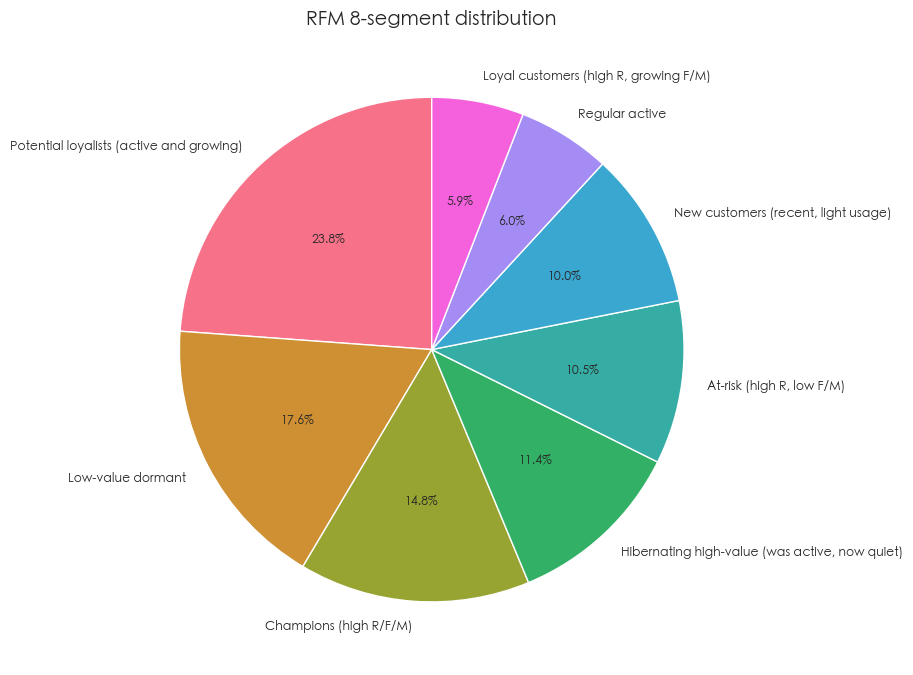

In [3]:
import seaborn as sns

seg_counts = rfm['segment'].value_counts()
fig, ax = plt.subplots(figsize=(9, 9))
colors_palette = sns.color_palette("husl", len(seg_counts))
wedges, texts, autotexts = ax.pie(seg_counts.values, labels=seg_counts.index,
                                    autopct='%1.1f%%', colors=colors_palette,
                                    startangle=90, textprops={'fontsize': 9})
ax.set_title("RFM 8-segment distribution")
save_fig(fig, "03_rfm_segment_pie")
plt.show()

Per-segment RFM means:
                                                  R       F      M
segment                                                           
At-risk (high R, low F/M)                       0.3   220.7   28.0
Champions (high R/F/M)                          0.1  3181.6  189.9
Hibernating high-value (was active, now quiet)  2.4  1214.5  100.3
Low-value dormant                               5.6   167.2   21.7
Loyal customers (high R, growing F/M)           0.1  1415.5  102.0
New customers (recent, light usage)             0.1   699.4   69.3
Potential loyalists (active and growing)        0.4  1607.4  116.3
Regular active                                  2.2   457.6   52.5


  -> saved: images/03_rfm_segment_radar.png


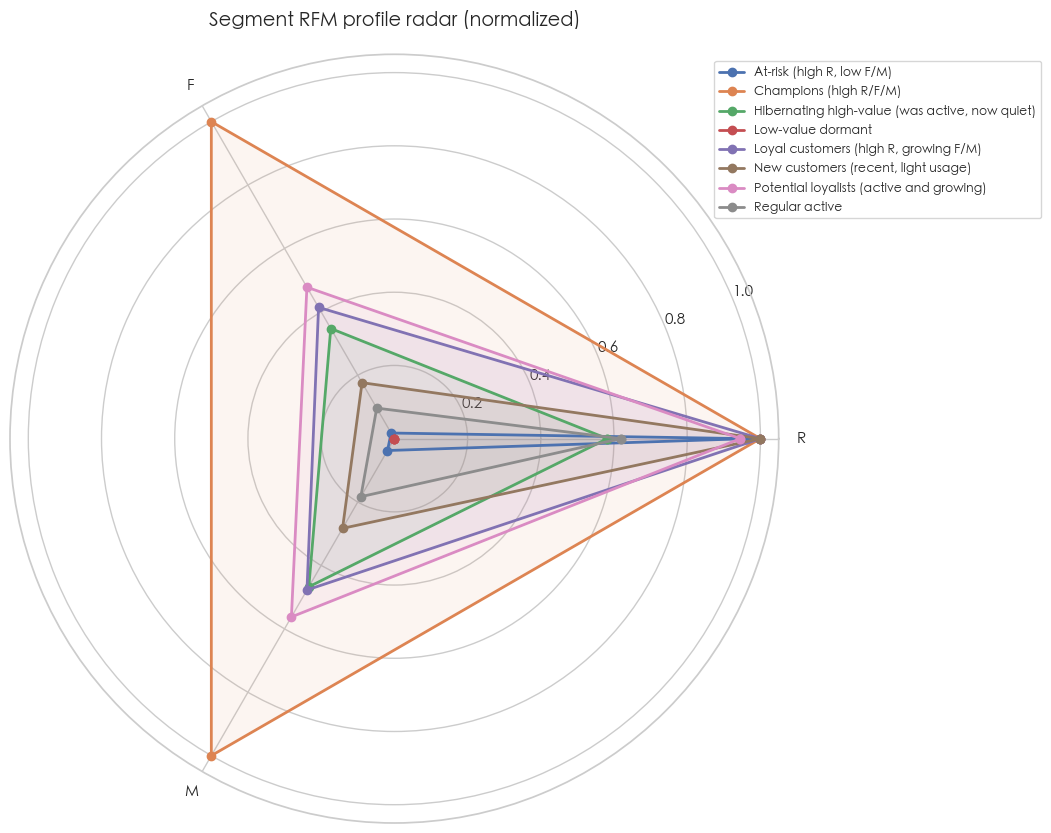

In [4]:
# Per-segment RFM profile
seg_profile = rfm.groupby('segment')[['R', 'F', 'M']].mean().round(1)
print("Per-segment RFM means:")
print(seg_profile)

# Radar chart (normalized)
fig, ax = plt.subplots(figsize=(10, 9), subplot_kw=dict(projection='polar'))
metrics = ['R', 'F', 'M']
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

# Normalize to 0-1 (R is reverse: smaller R = better, so invert)
seg_norm = (seg_profile - seg_profile.min()) / (seg_profile.max() - seg_profile.min())
seg_norm['R'] = 1 - seg_norm['R']

for seg in seg_profile.index:
    values = seg_norm.loc[seg].tolist()
    values += values[:1]
    ax.plot(angles, values, label=seg, linewidth=2, marker='o')
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_title("Segment RFM profile radar (normalized)", pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.0), fontsize=9)
save_fig(fig, "03_rfm_segment_radar")
plt.show()

In [5]:
# Export for later use
out_cols = ['user_id', 'R', 'F', 'M', 'R_score', 'F_score', 'M_score', 'RFM_sum', 'segment']
rfm[out_cols].to_csv(str(DERIVED_DIR / 'rfm_segments.csv'), index=False)
print(f"Exported: rfm_segments.csv ({len(rfm):,} rows)")

# Purchase rate by segment
df_with_seg = df.merge(rfm[['user_id', 'segment']], on='user_id')
seg_purchase_rate = (
    df_with_seg.assign(purchased=df_with_seg['behavior_type'] == 4)
    .groupby('segment')['purchased'].mean()
    .sort_values(ascending=False)
)
print("\nPurchase rate by segment:")
print(seg_purchase_rate.apply(lambda x: f"{x*100:.2f}%"))

Exported: rfm_segments.csv (10,000 rows)



Purchase rate by segment:
segment
At-risk (high R, low F/M)                         1.95%
Low-value dormant                                 1.79%
New customers (recent, light usage)               1.32%
Regular active                                    1.25%
Potential loyalists (active and growing)          0.98%
Loyal customers (high R, growing F/M)             0.94%
Hibernating high-value (was active, now quiet)    0.90%
Champions (high R/F/M)                            0.85%
Name: purchased, dtype: object


## Conclusion and differentiated operation recommendations

### 8 segment characteristics

(Review pie chart for sizes and radar chart for behavior profiles)

**Champions** (high R/F/M): core active users — most valuable, prioritize retention
**Loyal customers** (high R, growing F/M): engaged users with growth potential
**At-risk** (high R, low F/M): used to be active, now quiet — recall priority
**Hibernating high-value** (was active, now quiet): high historic value, dormancy risk
**New customers** (recent, light usage): just acquired — nurture to second purchase
**Potential loyalists** (active and growing): promising — guide to higher engagement
**Low-value dormant**: low priority, avoid disturbing
**Regular active**: stable middle-tier users

### Differentiated operation strategies

1. **Champions**: VIP service, early access to new products
   - Expected: maintain loyalty, prevent downgrade to At-risk

2. **Hibernating high-value**: targeted recall with high-discount coupons
   - Expected: reactivate 10-20% of this segment

3. **New customers**: onboarding nudges, first-purchase incentives
   - Expected: convert to Regular active

4. **At-risk**: re-engagement campaigns, personalized recommendations
   - Expected: reduce churn

5. **Low-value dormant**: low-priority, batch marketing
   - Expected: save marketing budget